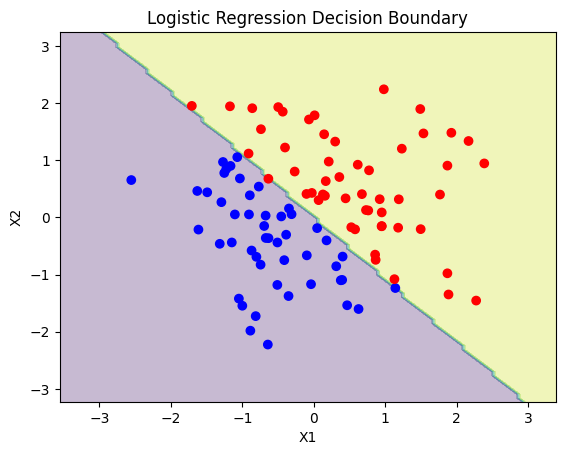

In [8]:
# Logistic Regression From Scratch
import numpy as np
import matplotlib.pyplot as plt

class LogisticRegression:
  def __init__(self, lr=0.01, num_iter=1000):
    self.lr = lr
    self.num_iter = num_iter

  def sigmoid(self, z):
    return 1 / (1 + np.exp(-z))

  def fit(self, X, y):
    self.w = np.zeros(X.shape[1])
    self.b = 0

    for i in range(self.num_iter):
      linear_model = np.dot(X, self.w) + self.b
      y_pred = self.sigmoid(linear_model)

      # Compute gradients
      dw = (1/X.shape[0]) * np.dot(X.T, (y_pred - y))
      db = (1/X.shape[0]) * np.sum(y_pred - y)

      # Update
      self.w -= self.lr * dw
      self.b -= self.lr * db

  def predict_proba(self, X):
    return self.sigmoid(np.dot(X, self.w) + self.b)
  def predict(self, X, threshold=0.5):
    return(self.predict_proba(X) >= threshold).astype(int)

# Test on toy data
np.random.seed(0)
X = np.random.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

model = LogisticRegression(lr=0.1, num_iter=500)
model.fit(X, y)

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:,0].max()+1, 100),
                     np.linspace(X[:, 1].min()-1, X[:,1].max()+1, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

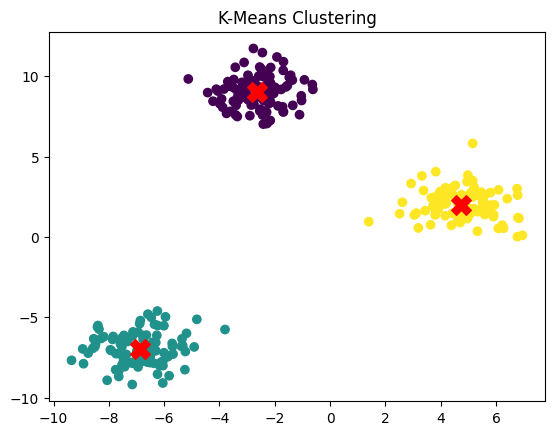

In [12]:
# K-Mean Clustering From Scratch
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
  def __init__(self, k=3, max_iters=100):
    self.k = k
    self.max_iters = max_iters

  def fit(self, X):
    # Random init centroids
    np.random.seed(42)
    self.centroids = X[np.random.choice(len(X), self.k, replace=False)]

    for _ in range(self.max_iters):
      # Assign clusters
      clusters = [np.argmin([np.linalg.norm(x-c) for c in self.centroids]) for x in X]
      # Update centroids
      new_centroids = np.array([X[np.array(clusters)==i].mean(axis=0) for i in range(self.k)])

      if np.allclose(new_centroids, self.centroids):
        break
      self.centroids = new_centroids
      self.labels_ = np.array(clusters)

# Test on synthetic data
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

kmeans = KMeans(k=3)
kmeans.fit(X)

plt.scatter(X[:,0], X[:,1], c=kmeans.labels_)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=200, marker='X', c='red')
plt.title('K-Means Clustering')
plt.show()